# LLM Time-Series Anomaly Detection: SFT Pipeline (Part 3)

---

## 阶段 0-C. 恢复环境（阶段 7 产物 tar 包）

### Cell 0-C.1 — 挂载 Google Drive、定义运行目录并安装依赖

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

RUNTIME    = Path("/content/tsad_runtime")
DRIVE_ROOT = Path("/content/drive/MyDrive/tsad_anomaly")

RT_CODE    = RUNTIME / "code"
RT_SFT     = RUNTIME / "sft"
RT_CKPT    = RUNTIME / "checkpoints"
RT_RESULTS = RUNTIME / "results"

DRV_PACK   = DRIVE_ROOT / "packs"
DRV_SFT    = DRIVE_ROOT / "sft"
DRV_CKPT   = DRIVE_ROOT / "checkpoints"
DRV_RESULTS= DRIVE_ROOT / "results"

for p in [RUNTIME, RT_CODE, RT_SFT, RT_CKPT, RT_RESULTS,
          DRV_PACK, DRV_SFT, DRV_CKPT, DRV_RESULTS]:
    p.mkdir(parents=True, exist_ok=True)

ANOMLLM = RT_CODE / "AnomLLM"

# !pip install -U pip -q
# !pip install "unsloth[colab-new]" -q
# !pip install vllm openai accelerate bitsandbytes scikit-learn pandas pyyaml datasets matplotlib pillow trl loguru google-generativeai requests -q
# !pip install "git+https://github.com/ahstat/affiliation-metrics-py.git" -q


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Cell 0-C.2 — 克隆仓库、恢复阶段 7 产物 tar 包并校验关键文件

In [5]:
import json
import os
import pickle
import subprocess
import tarfile

import pandas as pd

SUBSETS = ["flat-trend", "range", "point", "freq"]

if not ANOMLLM.exists():
    subprocess.run([
        "git", "clone", "https://github.com/Rose-STL-Lab/AnomLLM.git", str(ANOMLLM)
    ], check=True)

os.environ["PYTHONPATH"] = str(ANOMLLM / "src")

archives = sorted(DRV_PACK.glob("before_stage8_*.tar.gz"))
if not archives:
    raise FileNotFoundError(
        f"未找到 {DRV_PACK}/before_stage8_*.tar.gz。请先在 tsad_sft_pipeline_part2.ipynb 运行到阶段 7 末尾的打包 cell。"
    )

archive_path = archives[-1]
print(f"使用归档: {archive_path}")

with tarfile.open(archive_path, "r:gz") as tar:
    tar.extractall(RUNTIME)

required_sft = [
    RT_SFT / "sft_manifest.csv",
    RT_SFT / "sft_raw_smoke.jsonl",
    RT_SFT / "sft_raw.jsonl",
    RT_SFT / "sft_final.jsonl",
    RT_SFT / "train.jsonl",
    RT_SFT / "val.jsonl",
    RT_SFT / "eval.jsonl",
]
missing = [str(path) for path in required_sft if not path.exists() or path.stat().st_size == 0]
if missing:
    raise FileNotFoundError("恢复后缺少或为空的 SFT 文件:\n" + "\n".join(missing))

manifest = pd.read_csv(RT_SFT / "sft_manifest.csv")
split_counts = manifest["split"].value_counts().to_dict()
expected_counts = {"train": 1280, "val": 160, "eval": 160}
if split_counts != expected_counts:
    raise RuntimeError(f"split 分布异常: {split_counts}, expected={expected_counts}")
print("sft_manifest split counts:", split_counts)

def normalize_legacy_messages_jsonl(path):
    records = []
    needs_rewrite = False
    with open(path) as f:
        for line in f:
            record = json.loads(line)
            assistant_content = record["messages"][1]["content"]
            if isinstance(assistant_content, str):
                record["messages"][1]["content"] = [
                    {"type": "text", "text": assistant_content}
                ]
                needs_rewrite = True
            records.append(record)
    if needs_rewrite:
        with open(path, "w") as f:
            for record in records:
                f.write(json.dumps(record, ensure_ascii=False) + "\n")
        print(f"已修复旧版 assistant 格式: {path.name}")

for name in ["train.jsonl", "val.jsonl"]:
    normalize_legacy_messages_jsonl(RT_SFT / name)

with open(RT_SFT / "train.jsonl") as f:
    sample = json.loads(f.readline())
user_content = sample["messages"][0]["content"]
image_item = next(item for item in user_content if item["type"] == "image")
assistant_content = sample["messages"][1]["content"]
assistant_text = assistant_content[0].get("text") if isinstance(assistant_content, list) and assistant_content else None
try:
    assistant = json.loads(assistant_text) if assistant_text is not None else None
except json.JSONDecodeError:
    assistant = None
assistant_ok = (
    isinstance(assistant_content, list)
    and len(assistant_content) == 1
    and assistant_content[0].get("type") == "text"
    and isinstance(assistant_text, str)
    and isinstance(assistant, list)
    and all(isinstance(iv, dict) and {"start", "end"} <= set(iv) for iv in assistant)
)
print("train sample image exists:", Path(image_item["image"]).exists())
print("train sample assistant format ok:", isinstance(assistant_content, list))
print("train sample assistant json ok:", assistant_ok)
if not Path(image_item["image"]).exists() or not assistant_ok:
    raise RuntimeError("train.jsonl 样本校验失败")

baseline_path = RT_RESULTS / "baseline_compare.csv"
if not baseline_path.exists():
    raise FileNotFoundError(f"缺少恢复后的 baseline_compare.csv: {baseline_path}")
baseline_df = pd.read_csv(baseline_path)
print("baseline_compare.csv loaded:", baseline_df.shape)

for subset in SUBSETS:
    data_pkl = ANOMLLM / "data" / "synthetic" / subset / "eval" / "data.pkl"
    figs_dir = data_pkl.parent / "figs"
    qwen_jsonl = ANOMLLM / "results" / "synthetic" / subset / "qwen-local" / "0shot-vision.jsonl"
    iso_jsonl = ANOMLLM / "results" / "synthetic" / subset / "isolation-forest" / "0shot.jsonl"
    agg_pkl = ANOMLLM / "results" / "agg" / f"{subset}.pkl"

    required = [data_pkl, qwen_jsonl, iso_jsonl, agg_pkl]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError("恢复后缺少文件:\n" + "\n".join(missing))

    with open(data_pkl, "rb") as f:
        data = pickle.load(f)
    with open(agg_pkl, "rb") as f:
        _ = pickle.load(f)

    fig_count = len(list(figs_dir.glob("*.png")))
    series_count = len(data["series"])
    qwen_lines = sum(1 for _ in open(qwen_jsonl))
    iso_lines = sum(1 for _ in open(iso_jsonl))

    print(
        f"{subset}: series={series_count}, shape={data['series'][0].shape}, "
        f"figs={fig_count}, qwen_lines={qwen_lines}, iso_lines={iso_lines}"
    )

    if series_count != 400:
        raise RuntimeError(f"{subset} data.pkl 样本数异常: {series_count}, expected=400")
    if fig_count != 400:
        raise RuntimeError(f"{subset} figs 数量异常: {fig_count}, expected=400")
    if qwen_lines != 400 or iso_lines != 400:
        raise RuntimeError(
            f"{subset} baseline JSONL 行数异常: qwen={qwen_lines}, iso={iso_lines}, expected=400"
        )


使用归档: /content/drive/MyDrive/tsad_anomaly/packs/before_stage8_20260404_224304.tar.gz


/tmp/ipykernel_3008/4072696085.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(RUNTIME)


sft_manifest split counts: {'train': 1280, 'eval': 160, 'val': 160}
已修复旧版 assistant 格式: train.jsonl
已修复旧版 assistant 格式: val.jsonl
train sample image exists: True
train sample assistant format ok: True
train sample assistant json ok: True
baseline_compare.csv loaded: (8, 9)
flat-trend: series=400, shape=(1000, 1), figs=400, qwen_lines=400, iso_lines=400
range: series=400, shape=(1000, 1), figs=400, qwen_lines=400, iso_lines=400
point: series=400, shape=(1000, 1), figs=400, qwen_lines=400, iso_lines=400
freq: series=400, shape=(1000, 1), figs=400, qwen_lines=400, iso_lines=400


---
## 阶段 8. SFT 训练（Unsloth 官方范式）

### Cell 8.1 — 加载模型

In [6]:
!pkill -f "vllm.entrypoints.openai.api_server.*--port 8000" || true

from datasets import load_dataset
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-bnb-4bit",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,
    lora_alpha=16,
    lora_dropout=0.0,
    target_modules="all-linear",
)

train_dataset = load_dataset("json", data_files=str(RT_SFT / "train.jsonl"), split="train")
val_dataset   = load_dataset("json", data_files=str(RT_SFT / "val.jsonl"),   split="train")

^C
==((====))==  Unsloth 2026.4.2: Fast Qwen3_Vl patching. Transformers: 4.57.6. vLLM: 0.19.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

### Cell 8.2a — 训练冒烟（5 steps）

用 5 步验证训练流程无 OOM、loss 非 nan。

In [7]:
from trl import SFTConfig, SFTTrainer
from unsloth.trainer import UnslothVisionDataCollator

sft_args = SFTConfig(
    output_dir=str(RT_CKPT / "qwen3vl-tsad"),
    max_length=None,
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    bf16=True,
    logging_steps=1,
    eval_strategy="no",
    save_strategy="no",
    optim="adamw_8bit",
    report_to="none",
    remove_unused_columns=False,
    max_steps=5,  # 冒烟：仅 5 步
)

trainer = SFTTrainer(
    model=model,
    args=sft_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
)

trainer.train()

Unsloth: Model does not have a default image size - using 512


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,149 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 51,346,944 of 8,818,470,640 (0.58% trained)


Step,Training Loss
1,3.498300
2,3.491400
3,3.504000
4,3.417800
5,3.171400


TrainOutput(global_step=5, training_loss=3.4166003704071044, metrics={'train_runtime': 73.5657, 'train_samples_per_second': 0.544, 'train_steps_per_second': 0.068, 'total_flos': 345601263775680.0, 'train_loss': 3.4166003704071044, 'epoch': 0.034812880765883375})

### 📊 可视化：训练冒烟 Loss

/tmp/ipykernel_3008/669266537.py:12: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3008/669266537.py:12: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3008/669266537.py:12: UserWarning: Glyph 20882 (\N{CJK UNIFIED IDEOGRAPH-5192}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3008/669266537.py:12: UserWarning: Glyph 28895 (\N{CJK UNIFIED IDEOGRAPH-70DF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3008/669266537.py:12: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3008/669266537.py:12: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3008/669266537.py:12: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missi

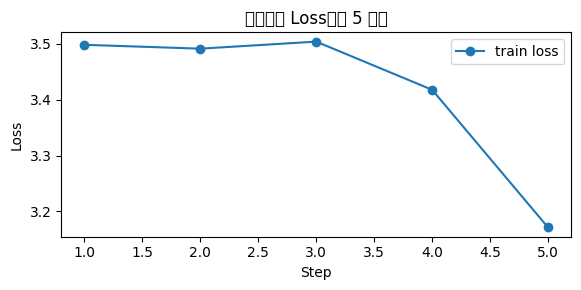

Loss 值: [3.4983, 3.4914, 3.504, 3.4178, 3.1714]
是否有 nan: False
✅ 冒烟通过，可以继续运行完整训练


In [8]:
import matplotlib.pyplot as plt, math

smoke_loss = [x["loss"] for x in trainer.state.log_history if "loss" in x]
steps = list(range(1, len(smoke_loss) + 1))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(steps, smoke_loss, "o-", label="train loss")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("训练冒烟 Loss（前 5 步）")
ax.legend()
fig.tight_layout()
plt.show()

has_nan = any(math.isnan(l) for l in smoke_loss)
print(f"Loss 值: {smoke_loss}")
print(f"是否有 nan: {has_nan}")
if has_nan:
    print("⚠️ 出现 nan，请勿继续，需要降低 learning_rate 后从 Cell 8.1 重跑")
elif smoke_loss[0] < 0.5 or smoke_loss[0] > 10:
    print(f"⚠️ 初始 loss={smoke_loss[0]:.2f} 偏离正常范围 [0.5, 10]，请检查")
else:
    print("✅ 冒烟通过，可以继续运行完整训练")

**⏸ 需要你判断**：检查上方 loss 曲线，确认 loss 在合理范围（1.5~4）且非 nan。若正常，继续运行下方完整训练 cell。

> 若 OOM → 需从 Cell 8.1 重新加载模型；若 loss=nan → 降低 lr 后重跑。

### Cell 8.2b — 完整训练

重新初始化 trainer 并进行完整训练（无 `max_steps` 限制）。

In [9]:
import gc, torch
del trainer, model
gc.collect()
torch.cuda.empty_cache()

# 重新加载模型（冒烟已污染权重）
from unsloth import FastVisionModel

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-bnb-4bit",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16, lora_alpha=16, lora_dropout=0.0,
    target_modules="all-linear",
)

from datasets import load_dataset
train_dataset = load_dataset("json", data_files=str(RT_SFT / "train.jsonl"), split="train")
val_dataset   = load_dataset("json", data_files=str(RT_SFT / "val.jsonl"),   split="train")

from trl import SFTConfig, SFTTrainer
from unsloth.trainer import UnslothVisionDataCollator

sft_args = SFTConfig(
    output_dir=str(RT_CKPT / "qwen3vl-tsad"),
    max_length=None,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    bf16=True,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    optim="adamw_8bit",
    report_to="none",
    remove_unused_columns=False,
)

trainer = SFTTrainer(
    model=model,
    args=sft_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
)

trainer.train()

==((====))==  Unsloth 2026.4.2: Fast Qwen3_Vl patching. Transformers: 4.57.6. vLLM: 0.19.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Unsloth: Model does not have a default image size - using 512


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,149 | Num Epochs = 3 | Total steps = 216
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 8 x 1) = 16
 "-____-"     Trainable parameters = 51,346,944 of 8,818,470,640 (0.58% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,0.054000,0.047647
200,0.045000,0.041622


TrainOutput(global_step=216, training_loss=0.3105181205879759, metrics={'train_runtime': 1515.1443, 'train_samples_per_second': 2.275, 'train_steps_per_second': 0.143, 'total_flos': 3.074499322318512e+16, 'train_loss': 0.3105181205879759, 'epoch': 3.0})

### 📊 可视化：完整训练 Loss 曲线

/tmp/ipykernel_3008/2967916651.py:17: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3008/2967916651.py:17: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3008/2967916651.py:17: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_3008/2967916651.py:17: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

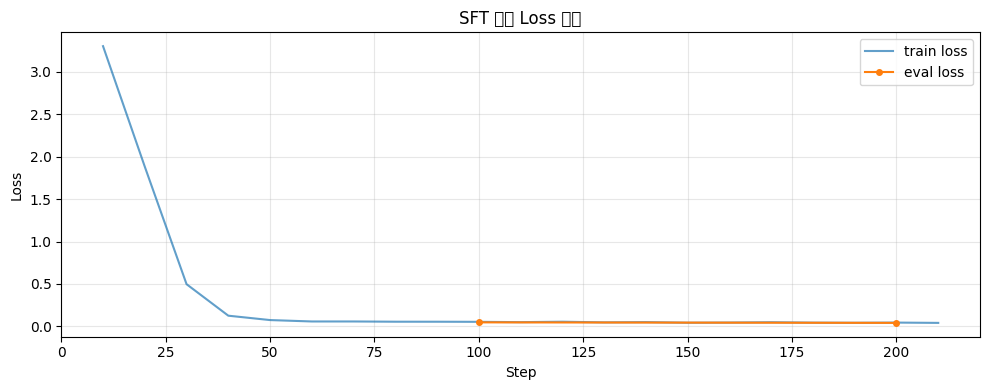

最终 train loss: 0.0415
最终 eval loss:  0.0416


In [10]:
import matplotlib.pyplot as plt

train_steps = [x["step"] for x in trainer.state.log_history if "loss" in x]
train_loss  = [x["loss"] for x in trainer.state.log_history if "loss" in x]
eval_steps  = [x["step"] for x in trainer.state.log_history if "eval_loss" in x]
eval_loss   = [x["eval_loss"] for x in trainer.state.log_history if "eval_loss" in x]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_steps, train_loss, label="train loss", alpha=0.7)
if eval_loss:
    ax.plot(eval_steps, eval_loss, "o-", label="eval loss", markersize=4)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("SFT 训练 Loss 曲线")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"最终 train loss: {train_loss[-1]:.4f}")
if eval_loss:
    print(f"最终 eval loss:  {eval_loss[-1]:.4f}")

---
## ⏸ 检查点 C：训练完成

检查上方 loss 曲线是否正常收敛，然后运行下方验证 cell。

In [11]:
import json, os

# 蒸馏质量：前 5 条
print("=== 蒸馏样本（前 5 条）===")
with open("/content/tsad_runtime/sft/sft_raw.jsonl") as f:
    for _ in range(5):
        print(json.dumps(json.loads(f.readline()), indent=2, ensure_ascii=False))

# 格式验证
print("\n=== 格式验证 ===")
with open("/content/tsad_runtime/sft/train.jsonl") as f:
    r = json.loads(f.readline())
user_content = r["messages"][0]["content"]
image_item = next(item for item in user_content if item["type"] == "image")
assistant_content = r["messages"][1]["content"]
assistant_text = assistant_content[0].get("text") if isinstance(assistant_content, list) and assistant_content else None
try:
    assistant = json.loads(assistant_text) if assistant_text is not None else []
except json.JSONDecodeError:
    assistant = []
assistant_ok = isinstance(assistant, list) and all(
    isinstance(iv, dict) and {"start", "end"} <= set(iv)
    for iv in assistant
)
print("image exists:", os.path.exists(image_item["image"]))
print("assistant format ok:", isinstance(assistant_content, list))
print("assistant json ok:", assistant_ok)
print("assistant preview:", assistant[:2])

=== 蒸馏样本（前 5 条）===
{
  "is_anomaly": false,
  "anomaly_type": "none",
  "intervals": [],
  "rationale": "The time series exhibits a consistent oscillatory pattern with gradually increasing amplitude and frequency. There are no sudden spikes, drops, or deviations from the expected trend that would indicate an anomaly.",
  "sample_id": "flat-trend_000",
  "image_path": "/content/tsad_runtime/code/AnomLLM/data/synthetic/flat-trend/eval/figs/001.png",
  "ground_truth": 0,
  "split": "train"
}
{
  "is_anomaly": false,
  "anomaly_type": "none",
  "intervals": [],
  "rationale": "The time series exhibits a consistent oscillatory pattern with gradually increasing amplitude and frequency. There are no sudden spikes, drops, or deviations from the expected trend that would indicate an anomaly.",
  "sample_id": "flat-trend_001",
  "image_path": "/content/tsad_runtime/code/AnomLLM/data/synthetic/flat-trend/eval/figs/002.png",
  "ground_truth": 0,
  "split": "train"
}
{
  "is_anomaly": false,
  "ano

### Cell 8.3 — 导出模型

训练完成后运行此 cell 导出。

In [12]:
model.save_pretrained_merged(RT_SFT / "qwen3vl-tsad-merged", tokenizer)
model.save_pretrained(RT_SFT / "qwen3vl-tsad-adapter")

config.json: 0.00B [00:00, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00004.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

model-00004-of-00004.safetensors:   0%|          | 0.00/2.72G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [01:30<00:00, 22.65s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [00:58<00:00, 14.57s/it]


Unsloth: Merge process complete. Saved to `/content/tsad_runtime/sft/qwen3vl-tsad-merged`


---
## 阶段 9. 对比 SFT 与 Baseline

baseline 在 400 条上算过指标，SFT eval 只有 160 条（跨 4 个子集）。**必须把 baseline 结果过滤到相同的 160 条**，才能公平对比。

### Cell 9.1 — 启动 SFT 模型 vLLM server 并推理

**⏸ 需要你判断**：运行后等待 vLLM 加载完成，确认 health check 返回 200 后再继续。

In [42]:
!pkill -f "vllm.entrypoints.openai.api_server.*--port 8000" || true

!pkill -f "vllm.entrypoints.openai.api_server.*--port 8001" || true


!nohup python -m vllm.entrypoints.openai.api_server \
  --model /content/tsad_runtime/sft/qwen3vl-tsad-merged \
  --served-model-name sft-model \
  --host 127.0.0.1 --port 8001 \
  --max-model-len 8192 \
  --gpu-memory-utilization 0.75 \
  > /tmp/sft-vllm.log 2>&1 &

^C
^C


In [53]:
!tail -n 80 /tmp/sft-vllm.log

(EngineCore pid=18874) [rank0]:W0404 23:47:38.337000 18874 torch/_inductor/remote_cache.py:372]     backend = RedisRemoteCacheBackend(cache_id)
(EngineCore pid=18874) [rank0]:W0404 23:47:38.337000 18874 torch/_inductor/remote_cache.py:372]               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
(EngineCore pid=18874) [rank0]:W0404 23:47:38.337000 18874 torch/_inductor/remote_cache.py:372]   File "/usr/local/lib/python3.12/dist-packages/torch/_inductor/remote_cache.py", line 259, in __init__
(EngineCore pid=18874) [rank0]:W0404 23:47:38.337000 18874 torch/_inductor/remote_cache.py:372]     raise RuntimeError("redis not available but required for remote cache")
(EngineCore pid=18874) [rank0]:W0404 23:47:38.337000 18874 torch/_inductor/remote_cache.py:372] RuntimeError: redis not available but required for remote cache
(EngineCore pid=18874) [rank0]:W0404 23:47:40.216000 18874 torch/_inductor/remote_cache.py:372] Unable to create a remote cache
(EngineCore pid=18874) [rank0]:W0404 23:47:40.216000

In [57]:
!curl -i http://127.0.0.1:8001/health

HTTP/1.1 200 OK
date: Sat, 04 Apr 2026 23:50:47 GMT
server: uvicorn
content-length: 0



In [62]:
import yaml

creds_path = ANOMLLM / "credentials.yml"
creds = yaml.safe_load(creds_path.read_text()) if creds_path.exists() else {}
creds["sft-model"] = {"api_key": "dummy", "base_url": "http://127.0.0.1:8001/v1"}
creds_path.write_text(yaml.safe_dump(creds, sort_keys=False))

65

In [59]:
import shutil

SUBSETS = ["flat-trend", "range", "point", "freq"]

for subset in SUBSETS:
    src = ANOMLLM / "data" / "synthetic" / subset / "eval" / "data.pkl"
    dst = ANOMLLM / "data" / "synthetic" / subset / "train" / "data.pkl"
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    print(f"copied: {src} -> {dst}")

copied: /content/tsad_runtime/code/AnomLLM/data/synthetic/flat-trend/eval/data.pkl -> /content/tsad_runtime/code/AnomLLM/data/synthetic/flat-trend/train/data.pkl
copied: /content/tsad_runtime/code/AnomLLM/data/synthetic/range/eval/data.pkl -> /content/tsad_runtime/code/AnomLLM/data/synthetic/range/train/data.pkl
copied: /content/tsad_runtime/code/AnomLLM/data/synthetic/point/eval/data.pkl -> /content/tsad_runtime/code/AnomLLM/data/synthetic/point/train/data.pkl
copied: /content/tsad_runtime/code/AnomLLM/data/synthetic/freq/eval/data.pkl -> /content/tsad_runtime/code/AnomLLM/data/synthetic/freq/train/data.pkl


In [60]:
%%bash
cd /content/tsad_runtime/code/AnomLLM
for datum in flat-trend range point freq; do
  python src/online_api.py --data "$datum" --model sft-model --variant 0shot-vision
done

Loaded dataset flat-trend with 400 series.
Loaded dataset flat-trend with 400 series.
Loaded dataset range with 400 series.
Loaded dataset range with 400 series.
Loaded dataset point with 400 series.
Loaded dataset point with 400 series.
Loaded dataset freq with 400 series.
Loaded dataset freq with 400 series.


/content/tsad_runtime/code/AnomLLM/src/gemini_api.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai
2026-04-04 23:52:22.817 | DEBUG    | openai_api:openai_client:31 - API key: ****ummy, endpoint: http://127.0.0.1:8001/v1
2026-04-04 23:52:24.648 | DEBUG    | openai_api:openai_client:31 - API key: ****ummy, endpoint: http://127.0.0.1:8001/v1
2026-04-04 23:52:24.810 | DEBUG    | openai_api:openai_client:31 - API key: ****ummy, endpoint: http://127.0.0.1:8001/v1
2026-04-04 23:52:24.978 | DEBUG    | openai_api:openai_client:31 - API key: ****ummy, endpoint: http://127.0.0.1:8001/v1
2026-04-04 23:52:25.144 | DEBUG    | openai_api:openai_client:31 - API key: ****ummy, endpoint: http://127.0.

### Cell 9.2 — 在相同的 eval 160 条上计算 SFT 与 baseline 指标

In [64]:
import os, json, sys, pickle, numpy as np, pandas as pd

os.chdir("/content/tsad_runtime/code/AnomLLM")
sys.path.insert(0, "/content/tsad_runtime/code/AnomLLM/src")

from utils import compute_metrics, interval_to_vector, load_results

# 1. 读取 eval split，建立 {subset: [pkl_idx, ...]} 映射
eval_manifest = pd.read_csv("/content/tsad_runtime/sft/sft_manifest.csv")
eval_manifest = eval_manifest[eval_manifest["split"] == "eval"]
eval_indices = {}
for subset, grp in eval_manifest.groupby("subset"):
    eval_indices[subset] = grp["pkl_idx"].tolist()

# 2. 加载 eval 数据集的 ground truth
gt_map = {}
for subset in ["flat-trend", "range", "point", "freq"]:
    with open(f"/content/tsad_runtime/code/AnomLLM/data/synthetic/{subset}/eval/data.pkl","rb") as f:
        d = pickle.load(f)
    for idx in eval_indices.get(subset, []):
        intervals = d["anom"][idx][0]
        gt_map[(subset, idx)] = interval_to_vector(
            [{"start": s, "end": e} for s, e in intervals]
        ).flatten()

# 3. 对每个方法提取 eval 样本的预测，计算指标
def eval_metrics(method_label, result_fn, eval_indices_map, gt_map):
    results_raw = load_results(result_fn, raw=False)
    rows = []
    for subset, idxs in eval_indices_map.items():
        for idx in idxs:
            pred = results_raw[idx]
            gt = gt_map[(subset, idx)]
            if pred is None:
                pred = np.zeros_like(gt)
            m = compute_metrics(gt.reshape(-1,1), pred.reshape(-1,1).astype(int))
            rows.append({"method": method_label, "subset": subset, **m})
    return pd.DataFrame(rows)

BASE_DIR = "/content/tsad_runtime/code/AnomLLM/results/synthetic"
all_frames = []
for subset in ["flat-trend", "range", "point", "freq"]:
    for method, fn in [
        ("isolation-forest", f"{BASE_DIR}/{subset}/isolation-forest/0shot.jsonl"),
        ("qwen-local-0shot",  f"{BASE_DIR}/{subset}/qwen-local/0shot-vision.jsonl"),
        ("sft-0shot",         f"{BASE_DIR}/{subset}/sft-model/0shot-vision.jsonl"),
    ]:
        all_frames.append(eval_metrics(method, fn, {subset: eval_indices[subset]}, gt_map))

result_df = pd.concat(all_frames)
summary = result_df.groupby("method")[["f1", "affi f1"]].mean().round(3)
print(summary)
summary.to_csv("/content/tsad_runtime/results/sft_eval_metrics.csv")


                     f1  affi f1
method                          
isolation-forest  0.110    0.476
qwen-local-0shot  0.440    0.629
sft-0shot         0.552    0.755


### 📊 可视化：SFT vs Baseline 最终对比

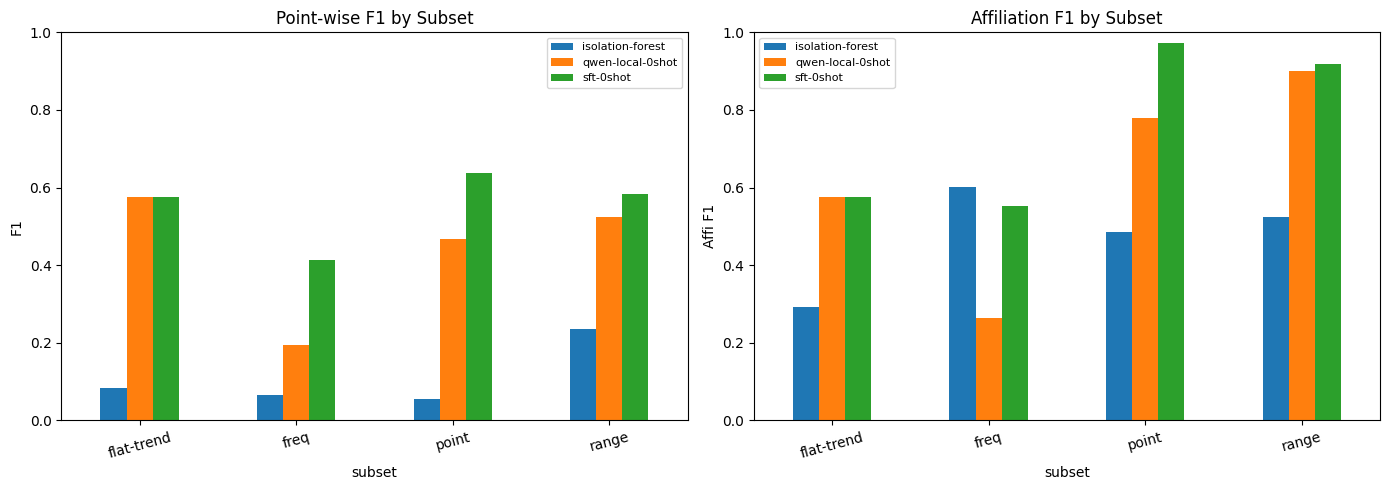

In [65]:
import matplotlib.pyplot as plt

pivot_f1 = result_df.groupby(["subset", "method"])["f1"].mean().unstack("method")
pivot_affi = result_df.groupby(["subset", "method"])["affi f1"].mean().unstack("method")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_f1.plot.bar(ax=axes[0], rot=15)
axes[0].set_title("Point-wise F1 by Subset")
axes[0].set_ylabel("F1")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)

pivot_affi.plot.bar(ax=axes[1], rot=15)
axes[1].set_title("Affiliation F1 by Subset")
axes[1].set_ylabel("Affi F1")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 1)

fig.tight_layout()
plt.show()

In [3]:
# Backup: Part 3 results only -> Drive (no model, no checkpoint)
import json
import tarfile
import time
from pathlib import Path

SUBSETS = ["flat-trend", "range", "point", "freq"]

# Optional: persist extra result tables if they are still in memory
if "result_df" in globals() and len(result_df) > 0:
    result_df.to_csv(RT_RESULTS / "sft_eval_detail.csv", index=False)

if "trainer" in globals() and getattr(trainer, "state", None) is not None:
    (RT_RESULTS / "sft_train_log_history.json").write_text(
        json.dumps(trainer.state.log_history, ensure_ascii=False, indent=2)
    )

ts = time.strftime("%Y%m%d_%H%M%S")
archive_path = DRV_PACK / f"part3_results_only_{ts}.tar.gz"
archive_path.parent.mkdir(parents=True, exist_ok=True)

sources = []
seen = set()

def add_file(path: Path, required=True):
    path = Path(path)
    if not path.exists():
        if required:
            raise FileNotFoundError(path)
        return
    if not path.is_file():
        if required:
            raise FileNotFoundError(f"Expected file, got: {path}")
        return
    key = str(path.resolve())
    if key in seen:
        return
    sources.append((path, path.relative_to(RUNTIME)))
    seen.add(key)

def add_tree(root: Path, required=True, pattern=None):
    root = Path(root)
    if not root.exists():
        if required:
            raise FileNotFoundError(root)
        return
    files = sorted(p for p in root.rglob(pattern or "*") if p.is_file())
    if required and not files:
        raise FileNotFoundError(f"Empty directory: {root}")
    for f in files:
        add_file(f)

# 1) Final result tables
required_result_files = [
    RT_RESULTS / "baseline_compare.csv",
    RT_RESULTS / "sft_eval_metrics.csv",
]
missing = [str(p) for p in required_result_files if not p.exists()]
if missing:
    raise FileNotFoundError("Missing result files:\n" + "\n".join(missing))

for p in required_result_files:
    add_file(p)

# Optional result files generated in notebook
add_file(RT_RESULTS / "sft_eval_detail.csv", required=False)
add_file(RT_RESULTS / "sft_train_log_history.json", required=False)

# 2) Keep manifest/jsonl used to define the eval split and labels
meta_files = [
    RT_SFT / "sft_manifest.csv",
    RT_SFT / "sft_final.jsonl",
    RT_SFT / "train.jsonl",
    RT_SFT / "val.jsonl",
    RT_SFT / "eval.jsonl",
]
missing = [str(p) for p in meta_files if not p.exists()]
if missing:
    raise FileNotFoundError("Missing SFT metadata files:\n" + "\n".join(missing))

for p in meta_files:
    add_file(p)

# 3) Keep baseline + SFT prediction outputs and original eval data for fair comparison
for subset in SUBSETS:
    required_subset_files = [
        ANOMLLM / "data" / "synthetic" / subset / "eval" / "data.pkl",
        ANOMLLM / "results" / "synthetic" / subset / "qwen-local" / "0shot-vision.jsonl",
        ANOMLLM / "results" / "synthetic" / subset / "isolation-forest" / "0shot.jsonl",
        ANOMLLM / "results" / "synthetic" / subset / "sft-model" / "0shot-vision.jsonl",
        ANOMLLM / "results" / "agg" / f"{subset}.pkl",
    ]
    missing = [str(p) for p in required_subset_files if not p.exists()]
    if missing:
        raise FileNotFoundError(f"Missing files for {subset}:\n" + "\n".join(missing))

    for p in required_subset_files:
        add_file(p)

with tarfile.open(archive_path, "w:gz") as tar:
    for abs_path, arc_name in sources:
        tar.add(abs_path, arcname=str(arc_name))

print(f"✅ 已打包 {len(sources)} 个文件 → {archive_path}")


✅ 已打包 28 个文件 → /content/drive/MyDrive/tsad_anomaly/packs/part3_results_only_20260405_004901.tar.gz


In [4]:
# Backup: final models only -> Drive (no checkpoint, no results)
import shutil
import time
from pathlib import Path

model_dirs = [
    RT_SFT / "qwen3vl-tsad-merged",
    RT_SFT / "qwen3vl-tsad-adapter",
]

missing = [str(p) for p in model_dirs if not p.exists()]
if missing:
    raise FileNotFoundError("Missing model dirs:\n" + "\n".join(missing))

ts = time.strftime("%Y%m%d_%H%M%S")
model_backup_root = DRV_SFT / f"part3_models_{ts}"
model_backup_root.mkdir(parents=True, exist_ok=True)

for src in model_dirs:
    dst = model_backup_root / src.name
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)

print(f"✅ 模型已保存到: {model_backup_root}")
for p in sorted(model_backup_root.iterdir()):
    print(" -", p)

✅ 模型已保存到: /content/drive/MyDrive/tsad_anomaly/sft/part3_models_20260405_005053
 - /content/drive/MyDrive/tsad_anomaly/sft/part3_models_20260405_005053/qwen3vl-tsad-adapter
 - /content/drive/MyDrive/tsad_anomaly/sft/part3_models_20260405_005053/qwen3vl-tsad-merged


---
## ⏸ 检查点 D：最终对比

查看上方图表：
- SFT 是否比 VLM zero-shot 有提升（F1 高 ≥ 0.03 为可见提升）
- 有无某个子集明显退步

> 进入 GRPO 需满足：SFT F1 高 ≥ 0.05、蒸馏保留率 ≥ 70%、还有剩余 session 时间。

---
## 阶段 10. 可选 GRPO

条件：baseline 对比完成 + SFT 有可见提升 + 蒸馏数据质量稳定。

沿用 Unsloth 官方 VLM RL/GRPO 范式，同一份 `train/val/eval` 数据。

**到达此阶段时，将检查点 D 的结果告诉 Claude Code，由其生成 GRPO 训练 cell。**